# Unit 4 · Hidden Markov models

Course: **21CSC305P — Machine Learning**

## Aim
Use a small two-state HMM to predict the next short or long waiting interval.

## Assignment tasks
1. Implement HMM to predict the sequential data.

## About this small dataset
Old Faithful is a geyser: a natural hot spring that sometimes shoots water into the air. This dataset has **299 eruptions and only two measurements**. Each row is one eruption, in the original recorded sequence.

**duration**: how long this eruption lasted, in minutes. **waiting**: how long people waited **before this eruption**, in minutes. There are no missing values, so we do not need to fill or remove them.

Source: [R MASS dataset documentation](https://stat.ethz.ch/R-manual/R-devel/library/MASS/html/geyser.html). Observations were collected August 1-15, 1985. Reference: Azzalini and Bowman (1990), *A look at some data on the Old Faithful geyser*. The supplied original CSV is from the Rdatasets mirror. We removed only its row-number column. Some night-time durations were recorded as 2, 3 or 4 minutes from short/medium/long descriptions.

Run the cells from top to bottom. Keep the `data` folder beside the `notebooks` folder. Learn each step by changing a value and rerunning the cell. These are small classroom demonstrations, not a complete prediction system.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Run from the project folder or from its notebooks folder.
try:
    df = pd.read_csv('data/geyser.csv')
except FileNotFoundError:
    df = pd.read_csv('../data/geyser.csv')

print('Number of eruptions:', len(df))

Number of eruptions: 299


## Understand the sequence
Keep the recorded order. A hidden state is a **short or long eruption** (`duration >= 3` means long). An observation is the **short or long wait after it** (`next_wait >= 70` means long). For training we reveal the eruption states and count transitions and emissions. During test predictions, we use only previously observed waits; upcoming durations and waits are hidden. This is a **supervised HMM demonstration**, which keeps training much simpler than Baum-Welch EM.

In [2]:
data = df.copy()
data['next_wait'] = data['waiting'].shift(-1)
data = data.dropna()
split = int(len(data) * 0.8)
states = (data['duration'] >= 3).astype(int).to_numpy()
observations = (data['next_wait'] >= 70).astype(int).to_numpy()
print('State 0 = short eruption; state 1 = long eruption')
print('Observation 0 = short wait; observation 1 = long wait')
display(data.head())

State 0 = short eruption; state 1 = long eruption
Observation 0 = short wait; observation 1 = long wait


,duration,waiting,next_wait
0,4.016667,80,71.0
1,2.150000,71,57.0
2,4.000000,57,80.0
3,4.000000,80,75.0
4,4.000000,75,77.0


## Step 1 · Learn two probability tables
`transition[i, j]` tells us how often state i is followed by state j. `emission[i, j]` tells us how often state i produces observation j. Starting counts at one prevents zero probabilities (add-one smoothing). Only the first 80% of rows contribute to these tables.

,Next short,Next long
Short eruption,0.012,0.988
Long eruption,0.555,0.445


,Short wait,Long wait
Short eruption,0.966,0.034
Long eruption,0.039,0.961


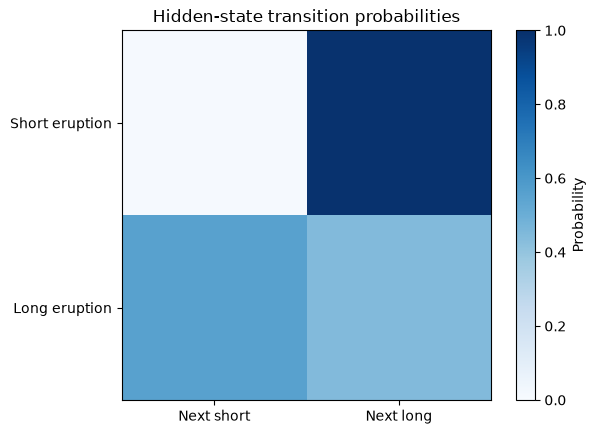

In [3]:
transition = np.ones((2, 2))
emission = np.ones((2, 2))
initial = np.ones(2)
initial[states[0]] += 1
initial = initial / initial.sum()

for i in range(split - 1):
    transition[states[i], states[i + 1]] += 1
for i in range(split):
    emission[states[i], observations[i]] += 1

transition = transition / transition.sum(axis=1, keepdims=True)
emission = emission / emission.sum(axis=1, keepdims=True)
display(pd.DataFrame(transition, index=['Short eruption', 'Long eruption'], columns=['Next short', 'Next long']).round(3))
display(pd.DataFrame(emission, index=['Short eruption', 'Long eruption'], columns=['Short wait', 'Long wait']).round(3))

plt.imshow(transition, vmin=0, vmax=1, cmap='Blues')
plt.xticks([0, 1], ['Next short', 'Next long'])
plt.yticks([0, 1], ['Short eruption', 'Long eruption'])
plt.colorbar(label='Probability')
plt.title('Hidden-state transition probabilities')
plt.show()

## Step 2 · Predict, then update
`belief` is our probability for each hidden state. Matrix multiplication predicts the next state, then the next observation. After making that prediction, we reveal the actual waiting category and update the belief. Dividing by the sum normalizes the forward filter and avoids extremely small accumulated probabilities.

HMM test accuracy: 0.683
Previous-wait baseline: 0.317
Probability the following wait is long: 0.469


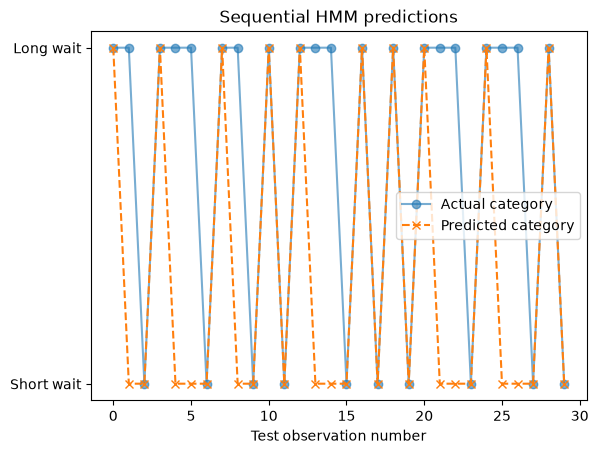

In [4]:
predictions = []
probabilities = []
belief = initial.copy()

for i, observation in enumerate(observations):
    if i == 0:
        next_state = belief
    else:
        next_state = belief @ transition
    next_observation = next_state @ emission

    # Record the test prediction BEFORE revealing this observation.
    if i >= split:
        predictions.append(int(np.argmax(next_observation)))
        probabilities.append(next_observation[1])

    belief = next_state * emission[:, observation]
    belief = belief / belief.sum()

from sklearn.metrics import accuracy_score
actual = observations[split:]
print('HMM test accuracy:', round(accuracy_score(actual, predictions), 3))
print('Previous-wait baseline:', round(accuracy_score(actual, observations[split - 1:-1]), 3))
print('Probability the following wait is long:', round(float((belief @ transition @ emission)[1]), 3))

plt.plot(actual[:30], 'o-', label='Actual category', alpha=0.6)
plt.plot(predictions[:30], 'x--', label='Predicted category')
plt.yticks([0, 1], ['Short wait', 'Long wait'])
plt.xlabel('Test observation number')
plt.title('Sequential HMM predictions')
plt.legend()
plt.show()

## What to explain
An ordinary Markov model would treat the observed wait category as the state. This HMM has a separate eruption state and a table connecting it to the observed wait. We know state labels during training, then hide them during filtering and prediction. We do not claim to learn unlabelled hidden states with EM.

**Try:** Inspect which transition has the largest probability.

**Viva:** What are the two states? What is an emission? Why do we predict before updating with the actual observation?